# Linear vs. nonlinear asymmetry between distance measures

`figs_summary_metrics_II.ipynb` shows an asymmetric Information Imbalance between
the RDMs that different distance measures build on the *same* neural population.
This notebook asks how much of that asymmetry a linear map can already account for.

The recipe, for one session and one timepoint:

1. compute the RDM of every measure (`euclidean`, `cosine`, `cosine_cnt`,
   `correlation`, `magnitude_diff`) on the same responses;
2. embed each RDM in Euclidean coordinates with classical MDS, keeping the
   components that reach 99% of the embedded variance;
3. run the shared asymmetry pipeline on every ordered pair of embeddings:
   pooled OLS R², II, and II after both spaces go through their reciprocal
   Sigma^-1 transform.

Step 2 is what makes the comparison possible: the pipeline needs point
coordinates, not dissimilarities. It is exact here because every measure in the
list is Euclidean-embeddable — `create_RDM` returns `1 - cos` for the cosine
family, which is already half a squared Euclidean distance, so
`RDM_IS_SQUARED_DISTANCE` tells classical MDS which RDMs to square and which not.
The `1 - II (raw RDM)` column checks this: it is II computed straight from the
original RDMs and must match the embedded II.

In [1]:
import os
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    (path for path in [cwd, *cwd.parents] if (path / "config.yaml").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate config.yaml from the current directory.")
# end if PROJECT_ROOT is None

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
with open(PROJECT_ROOT / "config.yaml", "r") as f:
    project_config = yaml.safe_load(f)
paths = project_config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stuff_path"])

from II_analyses.asymmetry_pipeline import (
    embed_measures_with_mds,
    mds_dimensionality_table,
    metric_asymmetry_table,
    participation_ratio,
)
from project_specific_utils.dataloader import load_img_natraster

plt.rcParams.update(
    {"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False}
)

In [2]:
@dataclass
class Cfg:
    monkey_name: str = "three0"
    date: str = "250313"
    brain_area: str = "AIT"
    new_fs: int = 100
    timepoint_idx: int = 17  # 170 ms at 100 Hz
    metrics: tuple = (
        "euclidean",
        "cosine",
        "cosine_cnt",
        "correlation",
        "magnitude_diff",
    )
    variance_explained: float = 0.99
    k: int = 1  # same k as the metric-comparison graphs of figs_summary_metrics_II
    singular_value_rtol: float | None = None
# EOC


cfg = Cfg()
metric_labels = {
    "euclidean": "euc",
    "cosine": "cos",
    "cosine_cnt": "cos_cnt",
    "correlation": "corr",
    "magnitude_diff": "mag",
}
cfg

Cfg(monkey_name='three0', date='250313', brain_area='AIT', new_fs=100, timepoint_idx=17, metrics=('euclidean', 'cosine', 'cosine_cnt', 'correlation', 'magnitude_diff'), variance_explained=0.99, k=1, singular_value_rtol=None)

## Load one timepoint

The raster is `(neurons, timepoints, images)`; `create_RDM` wants features in
rows and samples in columns, which is exactly one timepoint slice.

In [3]:
raster = load_img_natraster(
    paths,
    cfg.monkey_name,
    cfg.date,
    new_fs=cfg.new_fs,
    brain_area=cfg.brain_area,
)
raster_array = raster.get_array()
if not -raster_array.shape[1] <= cfg.timepoint_idx < raster_array.shape[1]:
    raise IndexError("timepoint_idx is outside the recorded time range.")
# end if timepoint_idx is invalid

timepoint_idx = cfg.timepoint_idx % raster_array.shape[1]
responses = raster_array[:, timepoint_idx, :].astype(float)  # (neurons, images)

print(f"raster: {raster_array.shape} (neurons, timepoints, images) at {raster.get_fs()} Hz")
print(f"timepoint {timepoint_idx} = {1000 * timepoint_idx / raster.get_fs():.0f} ms")
print(f"responses: {responses.shape} (neurons, images)")

raster: (25, 30, 776) (neurons, timepoints, images) at 100 Hz
timepoint 17 = 170 ms
responses: (25, 776) (neurons, images)


## MDS embedding of each measure

`negative eig. mass` is the share of eigenvalue mass that classical MDS has to
throw away because it is negative. It stays at machine precision here, which
confirms that all five measures embed exactly.

The **rank** columns separate the measures poorly, and that is structural rather
than a property of this session. All of these measures are Euclidean distances
between points obtained by a *pointwise* transform of the same `n_channels`-dimensional
cloud: `euclidean` is the identity, `cosine` rescales each point radially,
`cosine_cnt` translates then rescales, `correlation` projects onto the subspace
orthogonal to the all-ones vector then rescales, and `magnitude_diff` keeps only
the norm. A pointwise nonlinearity such as radial normalization curves the cloud
onto a sphere but stays inside the ambient space, so it cannot create new
dimensions; only an actual projection removes one. The rank is therefore capped
at `n_channels` and generically saturates it, which is why `correlation` (one
dimension lost to the per-image centering) and `magnitude_diff` (one-dimensional
by construction) are the only two that differ.

**PR**, the participation ratio, is the informative column. It is 1 when a single
eigenvalue dominates and `n` when all `n` eigenvalues are equal, so it reads the
shape of the spectrum rather than where the spectrum ends. `d50` and `d90` say the
same thing at two fixed points.

Because PR is scale-free it discards the amount of variance, which matters just as
much, so `total var` (the sum of the positive eigenvalues) and `top eig.` carry the
scale back. These live in each measure's own units: the cosine family is
dimensionless and bounded, `1 - cos` lying in `[0, 2]`, so `total var / n_images`
cannot exceed 1; `euclidean` and `magnitude_diff` are in squared response units and
can be compared with each other directly. That last pair is the useful one, and the
cell after the spectra uses it.

In [4]:
embeddings = embed_measures_with_mds(
    responses, cfg.metrics, variance_explained=cfg.variance_explained
)
dimensionality = mds_dimensionality_table(embeddings, metric_labels)
display(
    dimensionality.style.format(
        {
            "PR": "{:.2f}",
            "total var": "{:.1f}",
            "top eig.": "{:.1f}",
            "top eig. share": "{:.4f}",
            "negative eig. mass": "{:.2e}",
        }
    ).hide(axis="index")
)

measure,PR,d50,d90,total var,top eig.,top eig. share,dim (99% var),full rank,negative eig. mass
euc,14.61,7,21,1051.0,201.1,0.1913,25,25,4.72e-15
cos,19.43,9,21,633.0,78.8,0.1244,25,25,4.06e-15
cos_cnt,16.58,8,21,775.7,128.2,0.1653,25,25,3.91e-15
corr,21.20,9,21,722.7,65.7,0.0909,24,24,3.93e-15
mag,1.00,1,1,82.9,82.9,1.0000,1,1,8.30e-15


### Spectra

Left, the scree plot: the share of embedded variance carried by each MDS
component, on a log axis so the tails stay readable. Right, the same spectra
cumulated, with the 50% and 99% levels marked. The normalizing measures shave
down the leading component and leave a flatter tail, while the 99% level lands
at the end of every spectrum regardless.

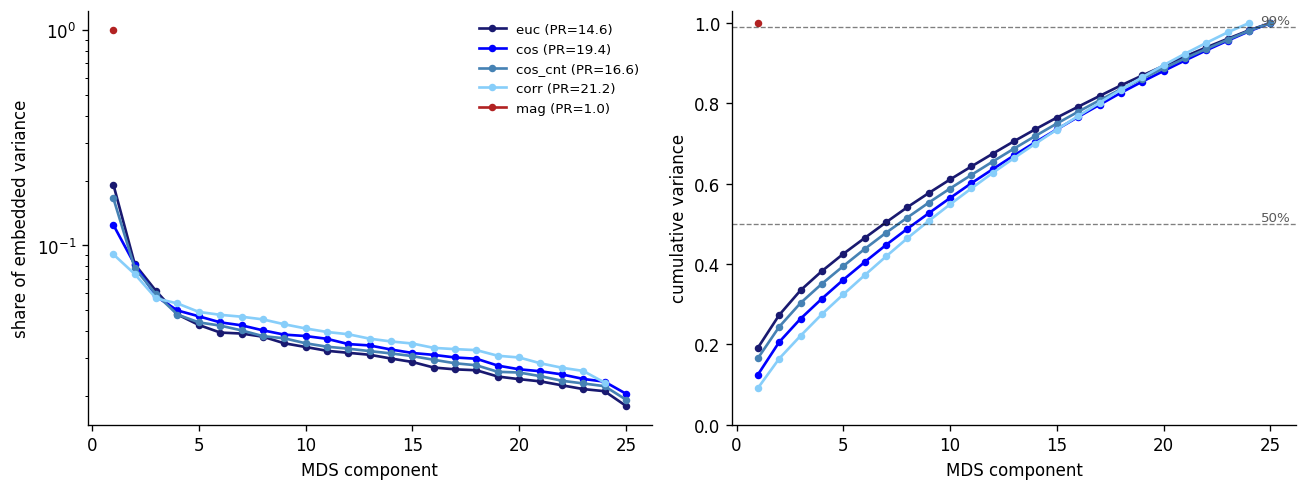

In [5]:
measure_colors = {
    "euclidean": "midnightblue",
    "cosine": "blue",
    "cosine_cnt": "steelblue",
    "correlation": "lightskyblue",
    "magnitude_diff": "firebrick",
}

fig, (ax_scree, ax_cumulative) = plt.subplots(1, 2, figsize=(11, 4.2))

for metric in cfg.metrics:
    embedding = embeddings[metric]
    shares = embedding["eigenvalue_shares"]
    cumulative = embedding["cumulative_variance"]
    components = np.arange(1, len(shares) + 1)
    label = (
        f"{metric_labels[metric]} (PR={embedding['participation_ratio']:.1f})"
    )
    style = dict(
        color=measure_colors[metric],
        marker="o",
        markersize=3.5,
        linewidth=1.6,
        label=label,
    )
    ax_scree.plot(components, shares, **style)
    ax_cumulative.plot(components, cumulative, **style)
# end for metric in cfg.metrics

ax_scree.set_yscale("log")
ax_scree.set(xlabel="MDS component", ylabel="share of embedded variance")
ax_scree.legend(frameon=False, fontsize=8)

# The two levels quoted in the dimensionality table.
for level in (0.5, cfg.variance_explained):
    ax_cumulative.axhline(level, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
    ax_cumulative.annotate(
        f"{level:.0%}",
        xy=(0.99, level),
        xycoords=("axes fraction", "data"),
        ha="right",
        va="bottom",
        fontsize=8,
        color="0.35",
    )
# end for level in (0.5, cfg.variance_explained)
ax_cumulative.set(xlabel="MDS component", ylabel="cumulative variance", ylim=(0, 1.03))

fig.tight_layout()
plt.show()

In [6]:
# The flatter spectra of the normalizing measures are the euclidean spectrum with
# its dominant component removed, not variance pushed out into new directions.
euclidean_shares = embeddings["euclidean"]["eigenvalue_shares"]
print(f"{'euc, all components':>22s} : {participation_ratio(euclidean_shares):.2f}")
for n_dropped in (1, 2, 3):
    print(
        f"{f'euc, top {n_dropped} dropped':>22s} : "
        f"{participation_ratio(euclidean_shares[n_dropped:]):.2f}"
    )
# end for n_dropped in (1, 2, 3)
for metric in ("cosine", "cosine_cnt", "correlation"):
    print(
        f"{metric_labels[metric]:>22s} : "
        f"{embeddings[metric]['participation_ratio']:.2f}"
    )
# end for metric in ("cosine", "cosine_cnt", "correlation")

   euc, all components : 14.61
    euc, top 1 dropped : 20.53
    euc, top 2 dropped : 21.00
    euc, top 3 dropped : 20.71
                   cos : 19.43
               cos_cnt : 16.58
                  corr : 21.20


### How much of the variance is magnitude?

`euclidean` and `magnitude_diff` are the two measures in squared response units, so
their totals are directly comparable and their ratio is exactly the share of the
cloud's variance that response magnitude accounts for. That share is small, yet the
component cosine suppresses carries more than twice as much — the dominant direction
is magnitude-*aligned* without being the norm.

In [7]:
norms = np.linalg.norm(responses, axis=0)  # ||x|| per image
centered = responses.T - responses.T.mean(axis=0)

variance_ratio = (
    embeddings["magnitude_diff"]["total_variance"]
    / embeddings["euclidean"]["total_variance"]
)
magnitude_share = norms.var() * len(norms) / (centered**2).sum()
print(f"total var(mag) / total var(euc)      : {variance_ratio:.4f}")
print(f"var(||x||) / total cloud variance    : {magnitude_share:.4f}")
print(f"euc top eigenvalue share             : {embeddings['euclidean']['eigenvalue_shares'][0]:.4f}")

# The dominant euclidean component is strongly magnitude-aligned but is not the norm.
scores = embeddings["euclidean"]["full_coordinates"][:, 0]
print(f"|corr(||x||, euc component 1)|       : {abs(np.corrcoef(norms, scores)[0, 1]):.4f}")

total var(mag) / total var(euc)      : 0.0788
var(||x||) / total cloud variance    : 0.0788
euc top eigenvalue share             : 0.1913
|corr(||x||, euc component 1)|       : 0.8452


## Directional table

- **R2**: pooled in-sample OLS R² of the source embedding predicting the target
  embedding. This is the purely linear part of the relation.
- **1 - II**: Information Imbalance between the two embeddings, the quantity
  plotted in `figs_summary_metrics_II.ipynb`. It is rank-based, so it also sees
  whatever a linear map cannot express.
- **1 - II (Sigma^-1)**: the same after each space is pushed through its
  reciprocal OLS map with the singular-value gains removed. Anything that
  survives here is asymmetry that a linear reweighting of the axes cannot undo.
- **1 - II (raw RDM)**: control, II computed directly on the original RDMs.

In [8]:
table = metric_asymmetry_table(
    embeddings,
    k=cfg.k,
    metric_labels=metric_labels,
    relative_tolerance=cfg.singular_value_rtol,
)
display(
    table.style.format(
        {
            "R2": "{:.4f}",
            "1 - II": "{:.4f}",
            "1 - II (Sigma^-1)": "{:.4f}",
            "1 - II (raw RDM)": "{:.4f}",
        }
    ).hide(axis="index")
)

embedding_error = np.abs(table["1 - II"] - table["1 - II (raw RDM)"]).max()
print(f"max |embedded II - raw RDM II| = {embedding_error:.2e}")

direction,dim source,dim target,R2,1 - II,1 - II (Sigma^-1),1 - II (raw RDM)
euc -> cos,25,25,0.9393,0.9911,0.9911,0.9911
cos -> euc,25,25,0.9342,0.9203,0.9203,0.9203
euc -> cos_cnt,25,25,0.9674,0.9920,0.9920,0.9920
cos_cnt -> euc,25,25,0.9670,0.9671,0.9671,0.9671
euc -> corr,25,24,0.9645,0.9850,0.9928,0.9850
corr -> euc,24,25,0.8657,0.8635,0.9656,0.8635
euc -> mag,25,1,0.7357,0.3594,0.4202,0.3594
mag -> euc,1,25,0.1378,0.2513,0.3976,0.2513
cos -> cos_cnt,25,25,0.9630,0.9910,0.9910,0.9910
cos_cnt -> cos,25,25,0.9656,0.9904,0.9904,0.9904


max |embedded II - raw RDM II| = 0.00e+00


## How much of the asymmetry is linear?

One row per unordered pair, with the asymmetry of each quantity written as the
difference between the two directions.

In [9]:
forward = table.iloc[::2].reset_index(drop=True)
backward = table.iloc[1::2].reset_index(drop=True)
asymmetry = pd.DataFrame(
    {
        "pair": [
            f"{f.split(' -> ')[0]} / {f.split(' -> ')[1]}" for f in forward["direction"]
        ],
        "dR2": forward["R2"] - backward["R2"],
        "d(1 - II)": forward["1 - II"] - backward["1 - II"],
        "d(1 - II) Sigma^-1": forward["1 - II (Sigma^-1)"]
        - backward["1 - II (Sigma^-1)"],
    }
)
display(
    asymmetry.style.format(
        {"dR2": "{:+.4f}", "d(1 - II)": "{:+.4f}", "d(1 - II) Sigma^-1": "{:+.4f}"}
    ).hide(axis="index")
)

pair,dR2,d(1 - II),d(1 - II) Sigma^-1
euc / cos,+0.0050,+0.0708,+0.0708
euc / cos_cnt,+0.0003,+0.0249,+0.0249
euc / corr,+0.0988,+0.1216,+0.0272
euc / mag,+0.5979,+0.1081,+0.0226
cos / cos_cnt,-0.0027,+0.0006,+0.0006
cos / corr,+0.0699,+0.0467,-0.0001
cos / mag,+0.3966,+0.0062,+0.0046
cos_cnt / corr,+0.0896,+0.0550,-0.0009
cos_cnt / mag,+0.5759,+0.0353,-0.0114
corr / mag,+0.2820,-0.0030,-0.0325


## Reading the Sigma^-1 column

When both embeddings keep the same number of components and the OLS map between
them is square and full rank, the Sigma^-1 row transform `V U^T` is orthogonal.
An orthogonal map preserves every pairwise Euclidean distance, hence every
distance rank, hence II exactly. So for those pairs the Sigma^-1 column is not
"the asymmetry that survives normalization": it is arithmetically forced to
equal the untransformed column, and it carries no extra information.

The column only moves for the pairs whose embeddings differ in dimensionality
(`corr`, one component short because of the per-image centering, and `mag`,
which is one-dimensional by construction). There the transform genuinely
projects one space into the other's rank and II changes.